In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
plt.style.use('seaborn-v0_8')

In [3]:
data = pd.read_csv('smaller.csv', dtype={'SOCP': str})
data['inc2024'] = data.PINCP * data.ADJINC / 1_000_000
print(data.shape, data.PWGTP.sum())

data = data.dropna(subset=['PWGTP', 'ADJINC', 'PINCP'])
print(data.shape, data.PWGTP.sum())

data = data[data.inc2024 > 0]
print(data.shape, data.PWGTP.sum())

(3422888, 7) 340110990
(2912790, 7) 280613270
(2556439, 7) 245168158


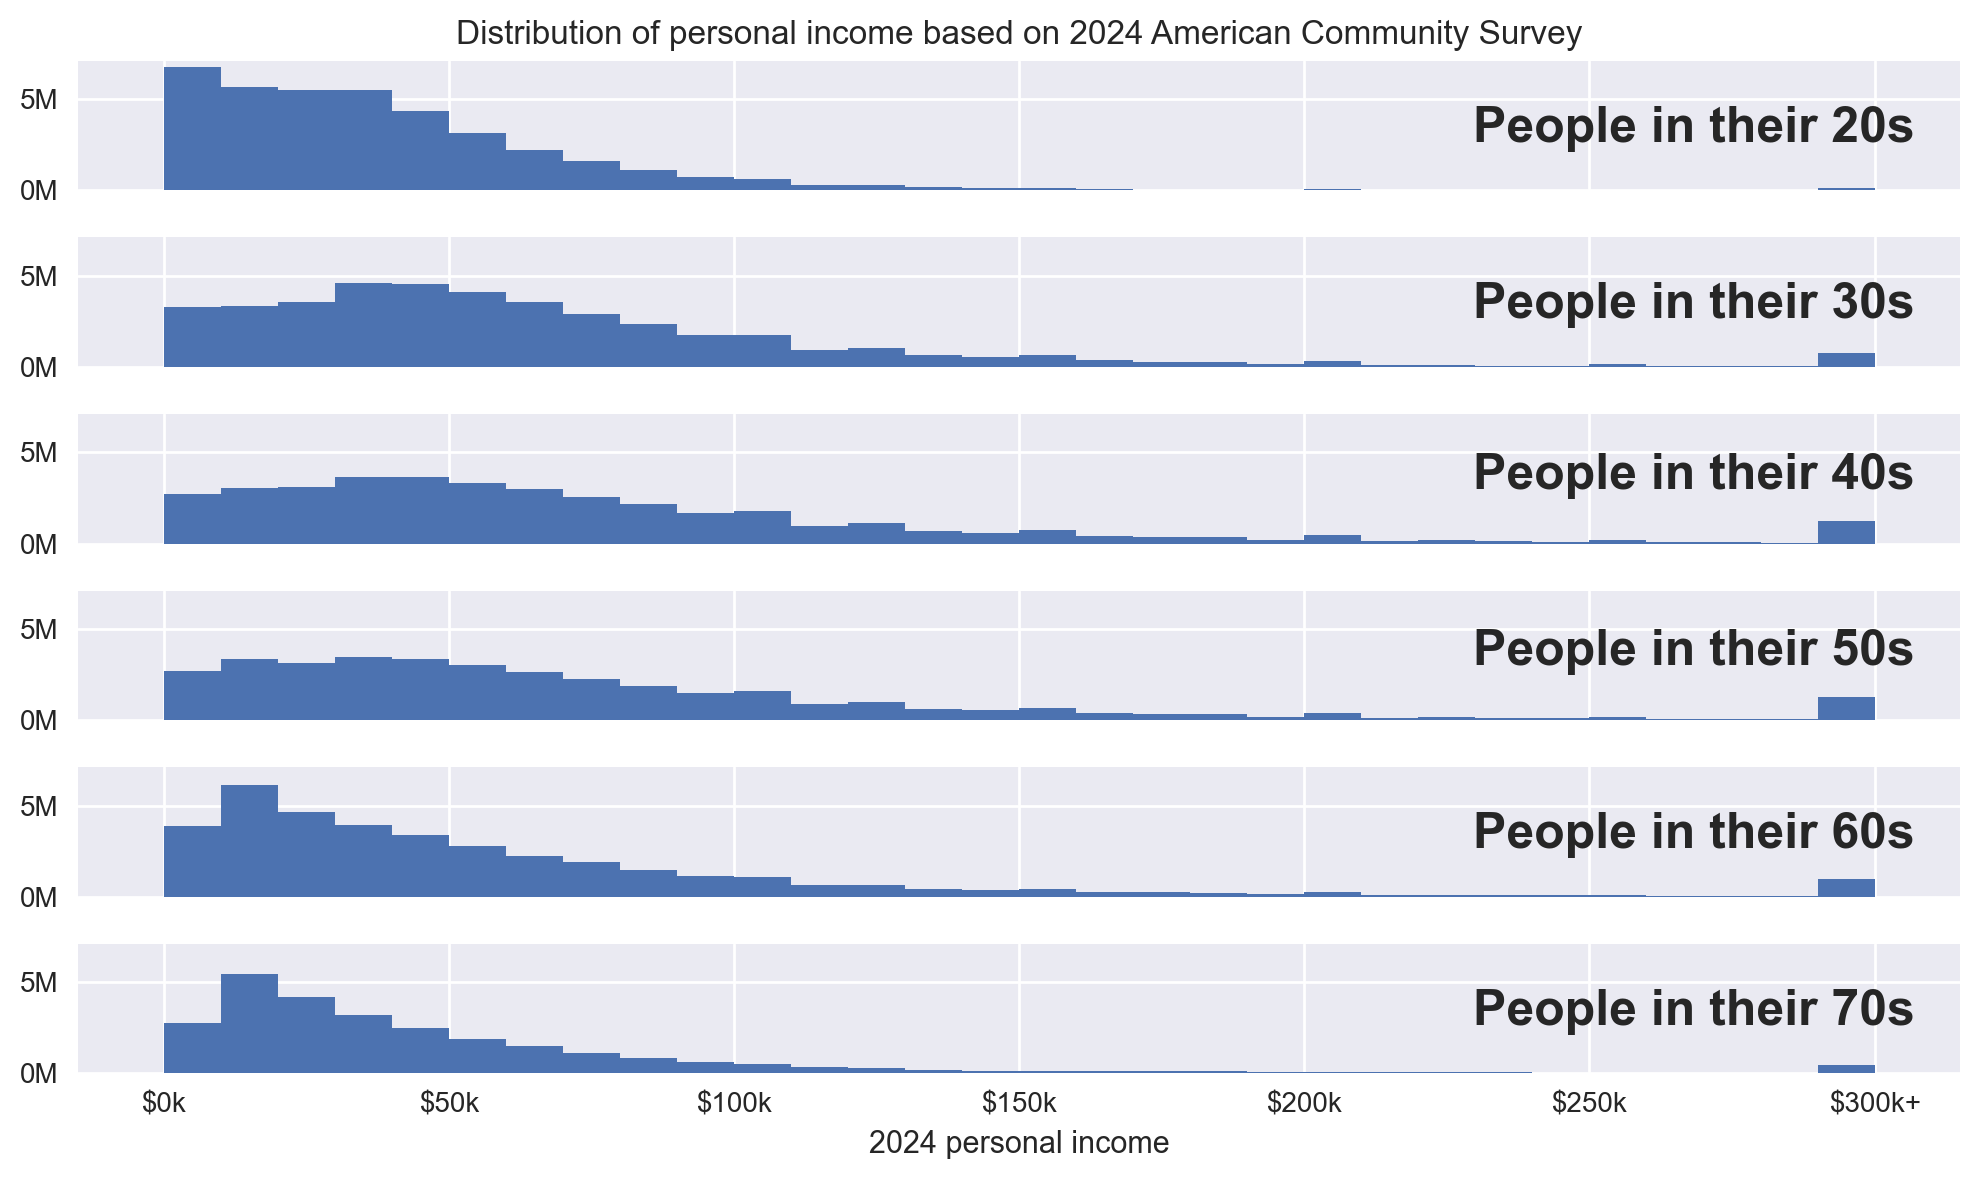

In [49]:
bins = range(0, 310_000, 10_000)

def fmtx(x, _):
    label = f'${int(x/1000)}k'
    if x == 300000:
        label += '+'
    return label

fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(10, 6), sharex=True, sharey=True)

for index, ax in enumerate(axes):
    group = data.AGEP // 10 == (index + 2)
    ax.hist(
        data.inc2024[group].clip(upper=300_000),
        weights=data.PWGTP[group],
        bins=bins,
        label=f'People in their {index + 2}0s')
    ax.legend(handlelength=0, handletextpad=0, prop={'size': 18, 'weight': 'bold'})

axes[-1].xaxis.set_major_formatter(mticker.FuncFormatter(fmtx))
plt.xlabel('2024 personal income')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
axes[0].set_title('Distribution of personal income based on 2024 American Community Survey')
plt.tight_layout()
plt.show()

(np.int64(15), np.int64(96))

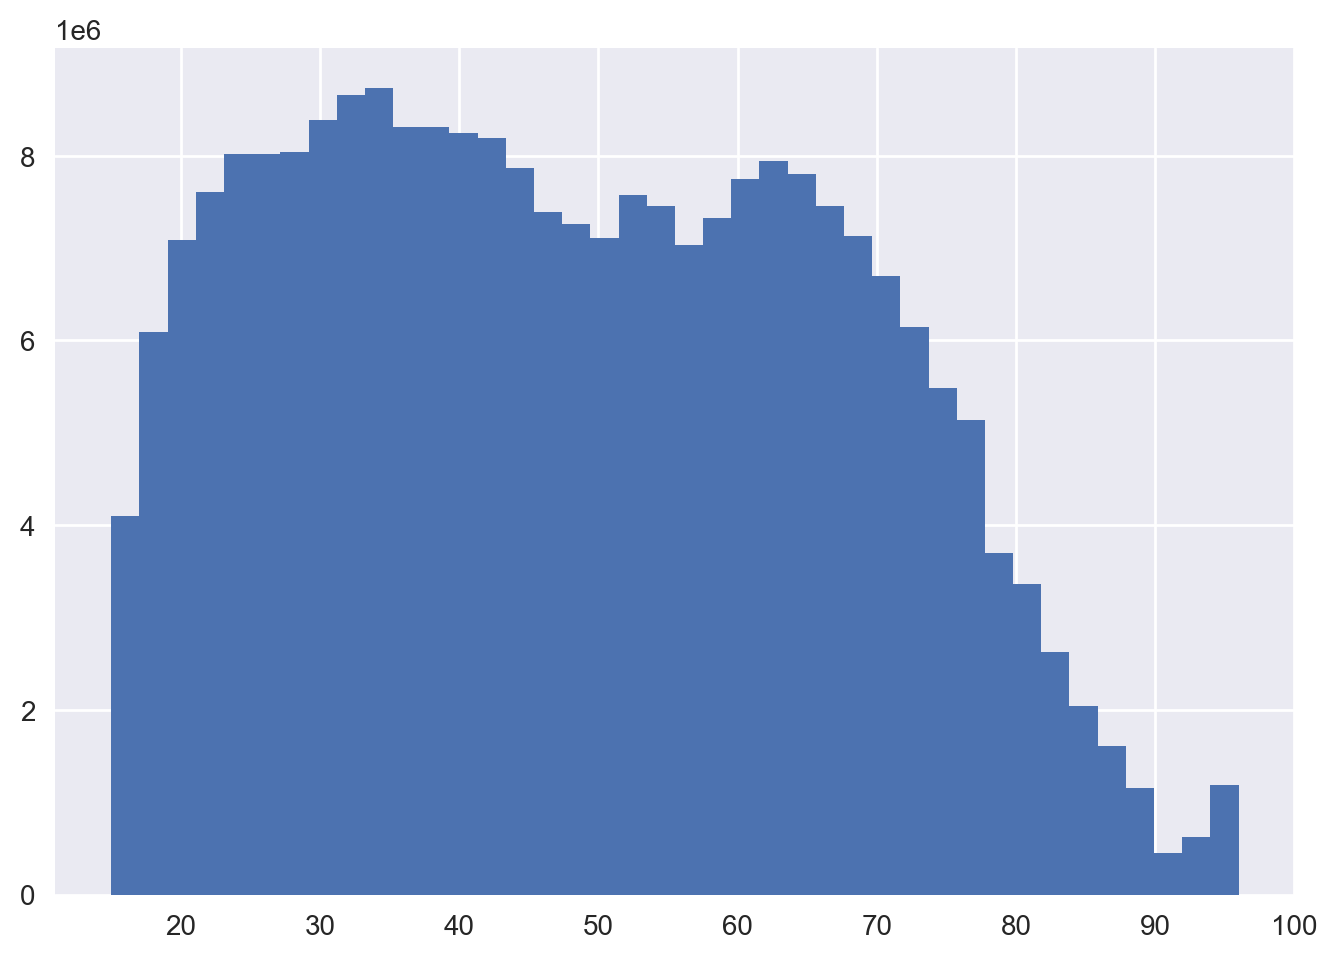

In [7]:
plt.hist(data.AGEP, weights=data.PWGTP, bins=40)
data.AGEP.min(), data.AGEP.max()